In [1]:
import cv2
import json
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import Qwen2TokenizerFast, Qwen3ForCausalLM, AutoConfig

from diffusers.utils import load_image
from diffusers.schedulers import FlowMatchEulerDiscreteScheduler
from diffusers.models import AutoencoderKLFlux2, Flux2Transformer2DModel

from ctgmworkshop.flux_tools import *
from ctgmworkshop.image_tools import *

device = "cuda"
dtype = torch.bfloat16
plt.style.use("dark_background")

In [2]:
vae = AutoencoderKLFlux2.from_pretrained("../../FLUX.2-klein-4B/vae", device=device).to(
    device
)
scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(
    "../../FLUX.2-klein-4B/scheduler", device=device
)

vae_mean, vae_std = get_latents_mean_std(vae)

In [3]:
train_batch_size = 16

In [4]:
class FlowRefractorDataset(Dataset):
    def __init__(self):
        self.all_cond_latents_A = torch.load(
            "../../precomputes/flow_refractor/test-6/all_cond_latents_A.pt"
        )
        self.all_cond_latents_B = torch.load(
            "../../precomputes/flow_refractor/test-6/all_cond_latents_B.pt"
        )
        self.all_final_latents_A = torch.load(
            "../../precomputes/flow_refractor/test-6/all_final_latents_A.pt"
        )
        self.all_final_latents_B = torch.load(
            "../../precomputes/flow_refractor/test-6/all_final_latents_B.pt"
        )

    def __len__(self):
        return len(self.all_cond_latents_A)

    def __getitem__(self, idx):
        return (
            self.all_cond_latents_A[idx],
            self.all_cond_latents_B[idx],
            self.all_final_latents_A[idx],
            self.all_final_latents_B[idx],
        )

In [5]:
dataset = FlowRefractorDataset()

In [6]:
print(
    dataset.all_cond_latents_A.shape,
    dataset.all_cond_latents_A.dtype,
    dataset.all_cond_latents_A.device,
)

torch.Size([10000, 32, 64, 120]) torch.float16 cpu


In [7]:
train_loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True)

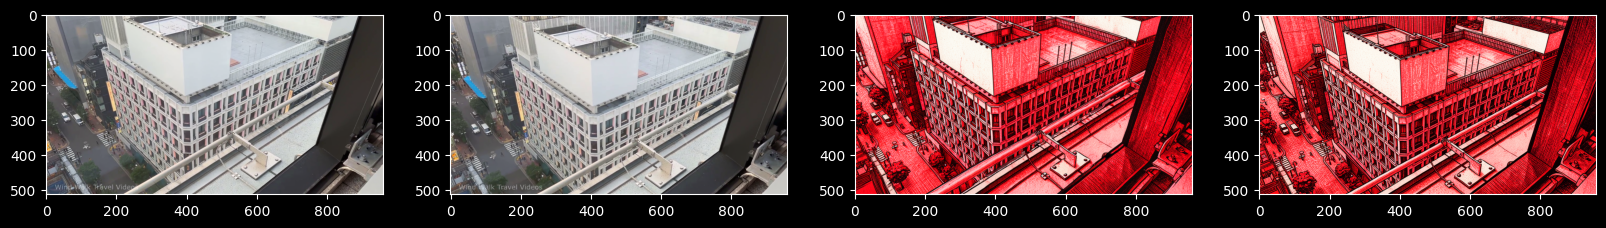

In [12]:
cond_A, cond_B, final_A, final_B = next(iter(train_loader))

fig, ax = plt.subplots(1, 4, figsize=(20, 5))

for i, l in enumerate([cond_A, cond_B, final_A, final_B]):
    with torch.no_grad():
        latents = denorm_unpatchified_latents(
            l[:1].cuda().float(), mean=vae_mean, std=vae_std
        )
        reconstructed = (vae.decode(latents[:1]).sample + 1.0) / 2.0

    reconstructed = reconstructed.squeeze(0).permute((1, 2, 0)).cpu().numpy()
    reconstructed = np.clip(reconstructed, 0, 1)

    ax[i].imshow(reconstructed)
plt.show()

In [13]:
def make_group_norm(
    channels: int, max_groups: int = 32, eps: float = 1e-6
) -> nn.GroupNorm:
    groups = min(max_groups, channels)
    while channels % groups != 0 and groups > 1:
        groups -= 1
    return nn.GroupNorm(groups, channels, eps=eps)


class AttentionBlock(nn.Module):
    def __init__(self, channels: int, num_heads: int = 8, head_dim: int = 64):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.attn_dim = num_heads * head_dim

        self.norm = make_group_norm(channels)

        self.to_q = nn.Conv2d(
            channels, self.attn_dim, kernel_size=1, stride=1, padding=0
        )
        self.to_k = nn.Conv2d(
            channels, self.attn_dim, kernel_size=1, stride=1, padding=0
        )
        self.to_v = nn.Conv2d(
            channels, self.attn_dim, kernel_size=1, stride=1, padding=0
        )

        self.to_out = nn.Conv2d(
            self.attn_dim, channels, kernel_size=1, stride=1, padding=0
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x

        b, c, H, W = x.shape

        h = self.norm(x)

        q = self.to_q(h)
        k = self.to_k(h)
        v = self.to_v(h)

        q = q.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)
        k = k.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)
        v = v.view(b, self.num_heads, self.head_dim, H * W).permute(0, 1, 3, 2)

        attn_out = F.scaled_dot_product_attention(q, k, v)

        attn_out = attn_out.permute(0, 1, 3, 2).reshape(b, self.attn_dim, H, W)

        out = self.to_out(attn_out)

        return out + residual


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int = 128, max_period: int = 10000):
        super().__init__()
        self.dim = dim
        self.max_period = max_period

    def forward(self, timesteps: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        timesteps = timesteps.float()

        freqs = torch.exp(
            -torch.log(torch.tensor(float(self.max_period), device=timesteps.device))
            * torch.arange(half, device=timesteps.device, dtype=timesteps.dtype)
            / half
        )
        args = timesteps[:, None] * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


class ConditioningEncoder(nn.Module):
    def __init__(self, time_dim: int = 128, cond_dim: int = 256):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)

        self.time_proj = nn.Sequential(
            nn.Linear(time_dim, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

    def forward(self, timestep: torch.Tensor) -> torch.Tensor:
        time_vec = self.time_proj(self.time_embed(timestep))
        return time_vec


class ConditionedResidualBlock(nn.Module):
    """
    SDXL-style residual block:
      GN -> SiLU -> Conv
      + condition (scale/shift)
      GN -> SiLU -> Dropout -> Conv
      + skip connection
    """

    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
    ):
        super().__init__()

        self.norm1 = make_group_norm(input_channels)
        self.conv1 = nn.Conv2d(
            input_channels, output_channels, kernel_size=3, padding=1
        )

        self.cond_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(cond_dim, 2 * output_channels),
        )

        self.norm2 = make_group_norm(output_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(
            output_channels, output_channels, kernel_size=3, padding=1
        )

        if input_channels != output_channels:
            self.skip = nn.Conv2d(
                input_channels, output_channels, kernel_size=1, bias=False
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        scale_shift = self.cond_proj(cond)
        scale, shift = scale_shift.chunk(2, dim=1)

        h = self.norm2(h)
        h = h * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return h + residual


class ResAttnStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()
        self.res = ConditionedResidualBlock(
            input_channels=input_channels,
            output_channels=output_channels,
            cond_dim=cond_dim,
            dropout=dropout,
        )
        self.attn = (
            AttentionBlock(output_channels, num_heads=num_heads)
            if use_attention
            else nn.Identity()
        )

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        x = self.res(x, cond)
        x = self.attn(x)
        return x


class DownStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        num_blocks: int = 1,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()

        attn_flags = [use_attention] * num_blocks

        self.blocks = nn.ModuleList()
        for i in range(num_blocks):
            in_ch = input_channels if i == 0 else output_channels
            self.blocks.append(
                ResAttnStage(
                    input_channels=in_ch,
                    output_channels=output_channels,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    use_attention=attn_flags[i],
                    num_heads=num_heads,
                )
            )

        self.downsample = nn.AvgPool2d(2)

    def forward(self, x: torch.Tensor, cond: torch.Tensor):
        for block in self.blocks:
            x = block(x, cond)
        skip = x
        x = self.downsample(x)
        return x, skip


class UpStage(nn.Module):
    def __init__(
        self,
        input_channels: int,
        skip_channels: int,
        output_channels: int,
        cond_dim: int = 256,
        dropout: float = 0.0,
        num_blocks: int = 1,
        use_attention: bool = False,
        num_heads: int = 4,
    ):
        super().__init__()

        attn_flags = [use_attention] * num_blocks

        self.upsample = nn.Upsample(
            scale_factor=2, mode="bilinear", align_corners=False
        )

        self.blocks = nn.ModuleList()
        for i in range(num_blocks):
            in_ch = (input_channels + skip_channels) if i == 0 else output_channels
            self.blocks.append(
                ResAttnStage(
                    input_channels=in_ch,
                    output_channels=output_channels,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    use_attention=attn_flags[i],
                    num_heads=num_heads,
                )
            )

    def forward(
        self, x: torch.Tensor, skip: torch.Tensor, cond: torch.Tensor
    ) -> torch.Tensor:
        x = self.upsample(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(
                x, size=skip.shape[-2:], mode="bilinear", align_corners=False
            )

        x = torch.cat([x, skip], dim=1)

        for block in self.blocks:
            x = block(x, cond)

        return x


class UNet(nn.Module):
    def __init__(
        self,
        sample_channels: int = 32,
        base_channels: int = 256,
        time_dim: int = 512,
        cond_dim: int = 1024,
        dropout: float = 0.01,
        num_heads: int = 4,
    ):
        super().__init__()

        self.conditioning = ConditioningEncoder(
            time_dim=time_dim,
            cond_dim=cond_dim,
        )

        self.in_conv = nn.Conv2d(
            sample_channels * 4, base_channels, kernel_size=1, padding=0
        )

        self.down_stages = nn.ModuleList(
            [
                DownStage(
                    input_channels=base_channels,
                    output_channels=base_channels,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    num_blocks=2,
                    use_attention=False,
                    num_heads=num_heads,
                ),
                DownStage(
                    input_channels=base_channels,
                    output_channels=base_channels * 2,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    num_blocks=4,
                    use_attention=True,
                    num_heads=num_heads,
                ),
            ]
        )

        self.mid_stages = nn.ModuleList(
            [
                ResAttnStage(
                    input_channels=base_channels * 2,
                    output_channels=base_channels * 2,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    use_attention=True,
                    num_heads=num_heads,
                )
                for _ in range(8)
            ]
        )

        self.up_stages = nn.ModuleList(
            [
                UpStage(
                    input_channels=base_channels * 2,
                    skip_channels=base_channels * 2,
                    output_channels=base_channels,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    num_blocks=4,
                    use_attention=True,
                    num_heads=num_heads,
                ),
                UpStage(
                    input_channels=base_channels,
                    skip_channels=base_channels,
                    output_channels=base_channels,
                    cond_dim=cond_dim,
                    dropout=dropout,
                    num_blocks=2,
                    use_attention=False,
                    num_heads=num_heads,
                ),
            ]
        )

        self.out_conv = nn.Conv2d(
            base_channels, sample_channels, kernel_size=1, padding=0
        )

    def forward(
        self, sample: torch.Tensor, timestep: torch.Tensor, conditioning: torch.Tensor
    ) -> torch.Tensor:
        cond = self.conditioning(timestep)

        x = torch.cat([sample, conditioning], dim=1)

        x = self.in_conv(x)

        skips = []
        for down in self.down_stages:
            x, skip = down(x, cond)
            skips.append(skip)

        for mid in self.mid_stages:
            x = mid(x, cond)

        for up in self.up_stages:
            x = up(x, skips.pop(), cond)

        x = self.out_conv(x)
        return x

In [14]:
unet = UNet()
unet = unet.to(device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)
num_train_timesteps = 1000

total_params = sum(p.numel() for p in unet.parameters())
print("Total params:", total_params / 1000000, "M")

Total params: 93.598496 M


In [15]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output


def _get_next_sample_index(save_directory):
    """
    Finds the next available integer index for sample files
    of the form sample_<index>.png or sample_epochX_<index>.png.
    """
    pattern = re.compile(r"sample_(?:epoch\d+_)?(\d+)\.png")
    max_index = -1

    for fname in os.listdir(save_directory):
        match = pattern.match(fname)
        if match:
            max_index = max(max_index, int(match.group(1)))

    return max_index + 1


def latents_to_np(latent):
    img = denorm_unpatchified_latents(latent, mean=vae_mean, std=vae_std)
    img = decode_latents(img, vae)
    img = denorm_image(img)
    return torch_to_np(img)


@torch.no_grad()
def generate_test_sample(
    save_directory="../../samples/flow_refractor/test-6",
    epoch_number=None,
    save=True,
):
    os.makedirs(save_directory, exist_ok=True)

    sample_index = _get_next_sample_index(save_directory)

    if epoch_number is not None:
        filename = f"sample_epoch{epoch_number}_{sample_index}.png"
    else:
        filename = f"sample_{sample_index}.png"

    save_path = os.path.join(save_directory, filename)

    cond_A, cond_B, final_A, final_B = next(iter(train_loader))

    cond_A = cond_A[:1].cuda().float()
    cond_B = cond_B[:1].cuda().float()
    final_A = final_A[:1].cuda().float()

    conditioning = torch.cat([cond_A, cond_B, final_A], dim=1)

    scheduler.set_timesteps(32, mu=1.0)
    latents = torch.normal(0, 1, (1, 32, 64, 120), dtype=torch.float32, device="cuda")

    unet.eval()

    for t in scheduler.timesteps:
        latent_model_input = latents
        t = t.to(device).view(1)
        predicted_noise = unet(
            sample=latent_model_input,
            timestep=t,
            conditioning=conditioning,
        )

        latents = scheduler.step(predicted_noise, t, latents).prev_sample

    image = latents_to_np(latents)

    clear_output(wait=True)
    if save:
        plt.imsave(save_path, image)
    plt.imshow(image)
    plt.axis("off")
    plt.show()


@torch.no_grad()
def test_model():
    cond_A, cond_B, final_A, final_B = next(iter(train_loader))

    cond_A = cond_A[:1].cuda().float()
    cond_B = cond_B[:1].cuda().float()
    final_A = final_A[:1].cuda().float()

    conditioning = torch.cat([cond_A, cond_B, final_A], dim=1)

    scheduler.set_timesteps(32, mu=1.0)
    latents = torch.normal(0, 1, (1, 32, 64, 120), dtype=torch.float32, device="cuda")

    unet.eval()

    for t in scheduler.timesteps:
        latent_model_input = latents
        t = t.to(device).view(1)
        predicted_noise = unet(
            sample=latent_model_input,
            timestep=t,
            conditioning=conditioning,
        )
        latents = scheduler.step(predicted_noise, t, latents).prev_sample

    latents = [cond_A, cond_B, final_A, latents]
    cond_image_A, cond_image_B, final_image_A, generated = map(latents_to_np, latents)

    fig, axes = plt.subplots(1, 4, figsize=(32, 8))
    axes[0].imshow(cond_image_A)
    axes[0].set_title("cond_image_A")

    axes[1].imshow(cond_image_B)
    axes[1].set_title("cond_image_B")

    axes[2].imshow(final_image_A)
    axes[2].set_title("final_image_A")

    axes[3].imshow(generated)
    axes[3].set_title("generated")

    plt.show()

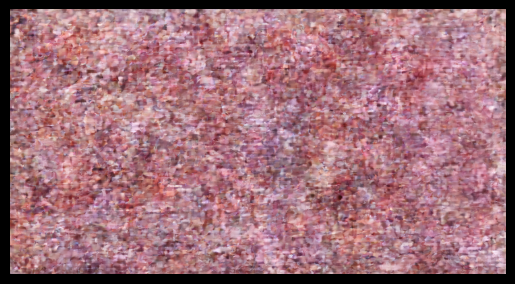

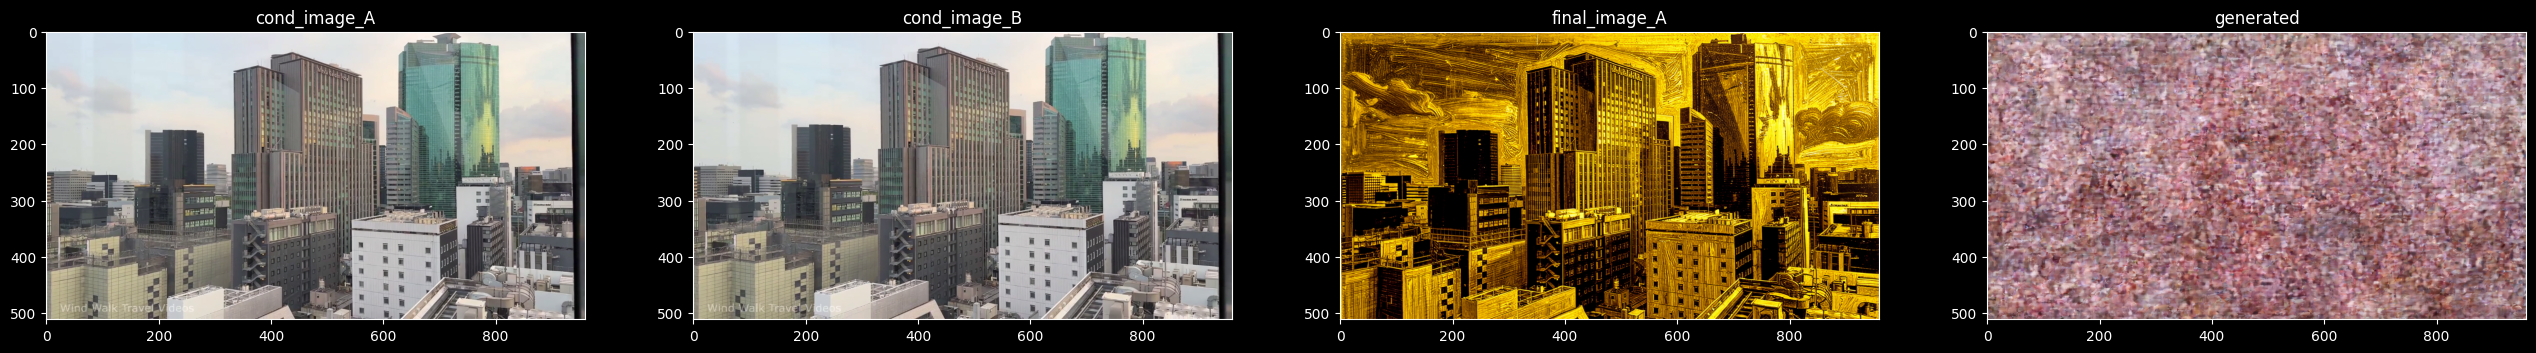

In [16]:
generate_test_sample()
test_model()

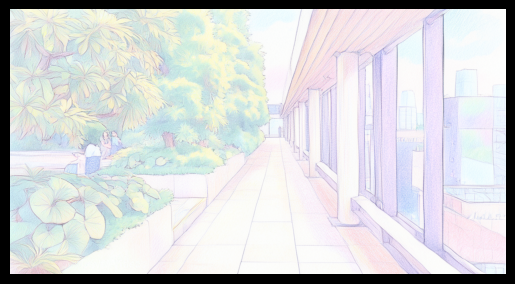

 16%|█▌        | 99/625 [00:29<02:36,  3.37it/s]

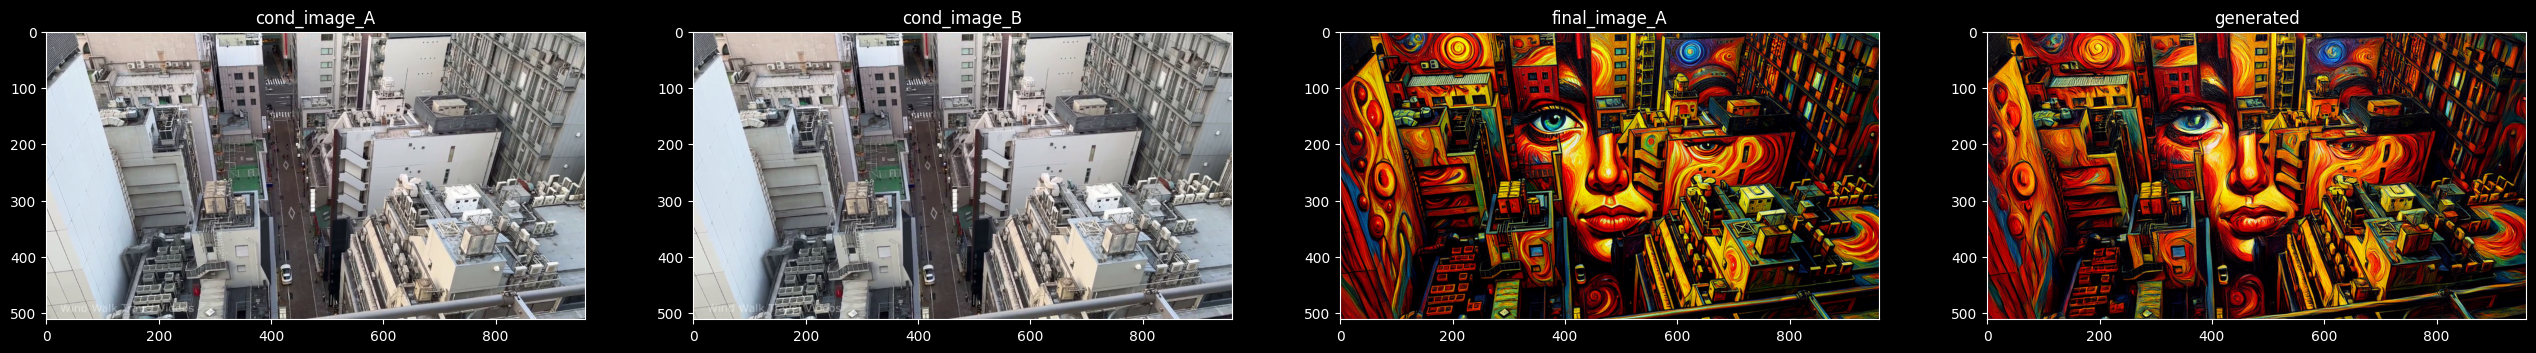

 23%|██▎       | 146/625 [00:43<02:24,  3.32it/s]


KeyboardInterrupt: 

In [ ]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="../../runs/flow_upscaler/test-6")

epochs = 1000

for epoch in range(0, epochs):
    num_steps = 0
    loss_sum = 0
    unet.train()
    for cond_A, cond_B, final_A, final_B in tqdm(train_loader):
        num_steps += 1

        batch_size = cond_A.shape[0]

        cond_A = cond_A.cuda().float()
        cond_B = cond_B.cuda().float()
        final_A = final_A.cuda().float()
        final_B = final_B.cuda().float()

        sigmas = torch.rand(batch_size, device=device)
        timesteps = sigmas * num_train_timesteps
        sigmas = sigmas[:, None, None, None]

        init = torch.normal(0, 1, cond_A.shape).cuda().float()

        noisy_latents = final_B * (1 - sigmas) + init * sigmas

        conditioning = torch.cat([cond_A, cond_B, final_A], dim=1)

        predicted_velocity = unet(
            sample=noisy_latents, timestep=timesteps, conditioning=conditioning
        )

        target = init - final_B

        loss = ((target - predicted_velocity) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += float(loss.item())

        if num_steps % 100 == 0:
            test_model()
            # unet.train()

    # generate_test_sample(epoch_number=epoch)
    # test_model()

    writer.add_scalar("train_loss", loss_sum / num_steps, epoch)
    generate_test_sample(epoch_number=epoch)

    # torch.save(unet.state_dict(), "../../trained_models/autosave.pth")

In [18]:
torch.save(unet.state_dict(), "../../trained_models/flow_refractor/test-6.pth")

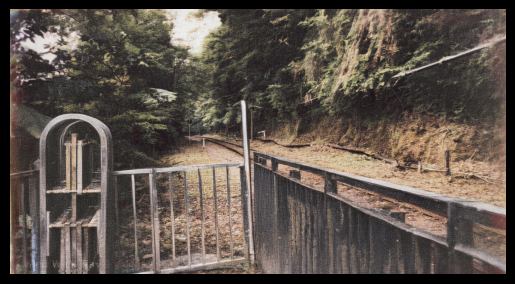

In [20]:
generate_test_sample()

In [18]:
state_dict = torch.load(
    "../../trained_models/flow_refractor/test-3.pth", weights_only=True
)
unet.load_state_dict(state_dict)

<All keys matched successfully>